# 📈 Stock Analyser - Multi-Timeframe (Next-Day & Next-Hour) Test Notebook
Tests API endpoints, SQLite Database, 1-Hour Intraday Feature Extraction, Next-Day Forecasts, and Next-Hour Forecasts.

In [1]:
import os
import sys
import requests
import sqlite3
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in sys.path
project_root = os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

BASE_URL = "http://127.0.0.1:8000"
print(f"✅ API Base URL: {BASE_URL}")

✅ API Base URL: http://127.0.0.1:8000


In [2]:
# 1. Test Stock Analysis API
ticker = "RELIANCE"
res = requests.get(f"{BASE_URL}/api/stock/{ticker}").json()

if res.get("status") == "success":
    latest = res.get("latest_ohlcv", {})
    pred = res.get("prediction", {})
    
    print(f"Stock Ticker      : {res.get('ticker')}")
    print(f"Latest Close      : ₹{latest.get('close', 'N/A')}")
    print(f"Predicted Target  : ₹{pred.get('predicted_close', 'N/A')}")
    print(f"Expected % Change : {pred.get('expected_pct_change', 'N/A')}%")
    print(f"Trend Signal      : {pred.get('trend_signal', 'N/A')}")
    print(f"Confidence        : {pred.get('confidence_pct', 'N/A')}%")

Stock Ticker      : RELIANCE.NS
Latest Close      : ₹1167.7
Predicted Target  : ₹1165.74
Expected % Change : -0.17%
Trend Signal      : BEARISH
Confidence        : 50.0%


In [3]:
# 2. Test Market Segmentation Scanner
seg_res = requests.get(f"{BASE_URL}/api/market/segmentation", params={"segment": "extreme_bullish"}).json()

if seg_res.get("status") == "success":
    counts = seg_res.get("sentiment_counts", {})
    print(f"Total Bullish: {seg_res.get('total_bullish')} | Total Bearish: {seg_res.get('total_bearish')}")
    print(f"Extreme Bullish Count: {counts.get('extreme_bullish', {}).get('count')}")
    
    df_extreme = pd.DataFrame(seg_res.get("stocks", []))
    display(df_extreme[["ticker", "company_name", "sector", "close", "predicted_close", "expected_pct_change", "confidence_pct"]].head(10))

Total Bullish: 260 | Total Bearish: 242
Extreme Bullish Count: 30


,ticker,company_name,sector,close,predicted_close,expected_pct_change,confidence_pct
0,SANSERA.NS,Sansera Engineering Ltd.,Automobile and Auto Components,4276.60,4436.81,3.75,66.6
1,WELCORP.NS,Welspun Corp Ltd.,Capital Goods,2605.80,2702.88,3.73,90.5
2,LEMONTREE.NS,Lemon Tree Hotels Ltd.,Consumer Services,107.67,110.28,2.43,54.9
3,CHENNPETRO.NS,Chennai Petroleum Corporation Ltd.,Oil Gas & Consumable Fuels,1346.40,1378.56,2.39,67.2
4,MPHASIS.NS,MphasiS Ltd.,Information Technology,2250.20,2303.27,2.36,82.1
5,ADANIPORTS.NS,Adani Ports and Special Economic Zone Ltd.,Services,1737.80,1774.18,2.09,65.8
6,KALYANKJIL.NS,Kalyan Jewellers India Ltd.,Consumer Durables,528.50,539.50,2.08,64.5
7,VBL.NS,Varun Beverages Ltd.,Fast Moving Consumer Goods,425.30,433.81,2.00,83.7
8,ADANIGREEN.NS,Adani Green Energy Ltd.,Power,1276.10,1299.42,1.83,53.7
9,MOTHERSON.NS,Samvardhana Motherson International Ltd.,Automobile and Auto Components,157.03,159.84,1.79,67.8


In [4]:
# 3. Test Dual Multi-Timeframe Forecast Engine (Next-Day & Next-Hour)
from src.models_registry import train_and_predict_stock

test_stock = "RELIANCE.NS"
df_d = yf.download(test_stock, period="1y", interval="1d", auto_adjust=True, progress=False)
df_h = yf.download(test_stock, period="60d", interval="1h", auto_adjust=True, progress=False)
if isinstance(df_d.columns, pd.MultiIndex): df_d.columns = df_d.columns.get_level_values(0)
if isinstance(df_h.columns, pd.MultiIndex): df_h.columns = df_h.columns.get_level_values(0)

# 1. Next-Day Forecast (Daily + 1-Hour Intraday Features)
pred_day = train_and_predict_stock(test_stock, df_d[["Open","High","Low","Close","Volume"]].dropna(), df_hourly=df_h[["Open","High","Low","Close","Volume"]].dropna(), mode="next_day")

# 2. Next-Hour Forecast (Intraday Hourly Candles)
pred_hour = train_and_predict_stock(test_stock, df_h[["Open","High","Low","Close","Volume"]].dropna(), mode="next_hour")

print("=== NEXT-DAY MOVEMENT FORECAST ===")
print(f"  • Reference Close : ₹{pred_day['reference_close']}")
print(f"  • Target Close    : ₹{pred_day['predicted_close']}")
print(f"  • Expected Change : {pred_day['expected_pct_change']}%")
print(f"  • Trend Signal    : {pred_day['trend_signal']}")
print(f"  • Confidence      : {pred_day['confidence_pct']}%")

print("=== NEXT-HOUR MOVEMENT FORECAST ===")
print(f"  • Reference Close : ₹{pred_hour['reference_close']}")
print(f"  • Target Close    : ₹{pred_hour['predicted_close']}")
print(f"  • Expected Change : {pred_hour['expected_pct_change']}%")
print(f"  • Trend Signal    : {pred_hour['trend_signal']}")
print(f"  • Confidence      : {pred_hour['confidence_pct']}%")

=== NEXT-DAY MOVEMENT FORECAST ===
  • Reference Close : ₹1167.7
  • Target Close    : ₹1161.38
  • Expected Change : -0.54%
  • Trend Signal    : BEARISH
  • Confidence      : 59.1%
=== NEXT-HOUR MOVEMENT FORECAST ===
  • Reference Close : ₹1167.7
  • Target Close    : ₹1166.66
  • Expected Change : -0.09%
  • Trend Signal    : BEARISH
  • Confidence      : 61.5%


In [5]:
# 4. Check SQLite Database Tables & Health
conn = sqlite3.connect("database/market_data.db")
cursor = conn.cursor()
tables = ["stocks_meta", "daily_ohlcv", "technical_indicators", "predictions", "market_analysis_daily"]
table_counts = []
for t in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {t}")
    table_counts.append({"Table Name": t, "Total Rows": f"{cursor.fetchone()[0]:,}"})
conn.close()
display(pd.DataFrame(table_counts))

,Table Name,Total Rows
0,stocks_meta,501
1,daily_ohlcv,"559,288"
2,technical_indicators,502
3,predictions,502
4,market_analysis_daily,1


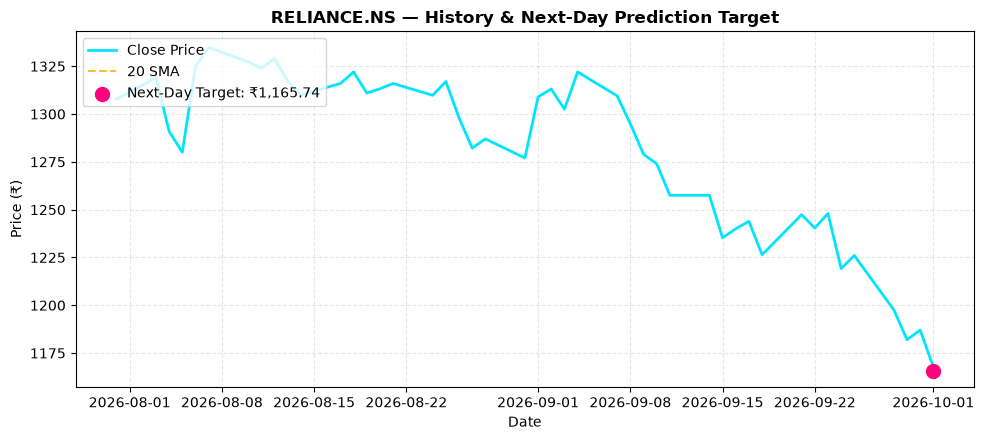

In [6]:
# 5. Plot Interactive Chart with Historical Prices & Tomorrow's Predicted Target
if res.get("status") == "success" and "chart_history" in res:
    history = pd.DataFrame(res["chart_history"])
    history["date"] = pd.to_datetime(history["date"])
    history = history.sort_values("date").tail(45)

    plt.figure(figsize=(10, 4.5))
    plt.plot(history["date"], history["close"], label="Close Price", color="#00e5ff", linewidth=2)
    if "sma_20" in history.columns:
        plt.plot(history["date"], history["sma_20"], label="20 SMA", color="#ffab00", linestyle="--", alpha=0.8)
    pred_val = res.get("prediction", {}).get("predicted_close")
    if pred_val:
        last_date = history["date"].iloc[-1]
        plt.scatter([last_date], [pred_val], color="#ff007f", s=100, zorder=5, label=f"Next-Day Target: ₹{pred_val:,.2f}")

    plt.title(f"{res.get('ticker')} — History & Next-Day Prediction Target", fontsize=12, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Price (₹)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()